# 6. Model Evaluation

This notebook evaluates the selected Gradient Boosting model on the held-out test set.The purpose of this stage is to determine whether the model's predicted probabilities provide a sufficiently useful ranking of 30-day readmission risk to support downstream patient prioritization and resource-allocation analysis.

Because the outcome is imbalanced, **PR-AUC remains the primary evaluation metric**, while **recall** is treated as the key operational metric. ROC-AUC, precision, F1-score, and accuracy are reported as supporting measures.

The held-out test set has not been used for model selection. Threshold analysis will be based on training or out-of-fold predictions to avoid using the test set for decision tuning.

## 6.1 Evaluation Setup

The modeling dataset, patient-aware train-test split, preprocessing pipeline, and selected Gradient Boosting model are reconstructed using the same specifications established during model development.

The held-out test set remains reserved for final evaluation and is not used for model selection or threshold tuning.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Load modeling data
df_model = pd.read_csv("../data/processed/modeling_data.csv")

# Restore administrative IDs as categorical variables
categorical_ids = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]
df_model[categorical_ids] = df_model[categorical_ids].astype(str)

# Patient-aware train-test split
X = df_model.drop(columns="readmitted_30")
y = df_model["readmitted_30"]
groups = df_model["patient_nbr"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = X_train["patient_nbr"].copy()
groups_test = X_test["patient_nbr"].copy()

X_train.drop(columns="patient_nbr", inplace=True)
X_test.drop(columns="patient_nbr", inplace=True)

# Preprocessing
numerical_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()

dense_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), categorical_cols)
])

# Selected model
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", dense_preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=100,
        random_state=42
    ))
])

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(
    "Patient overlap:",
    len(set(groups_train) & set(groups_test))
)
print(f"Training readmission rate: {y_train.mean():.2%}")
print(f"Test readmission rate: {y_test.mean():.2%}")

Training shape: (81670, 33)
Test shape: (20093, 33)
Patient overlap: 0
Training readmission rate: 11.22%
Test readmission rate: 10.92%


## 6.2 Out-of-Fold Training Predictions

Before evaluating the final model on the held-out test set, out-of-fold predicted probabilities are generated from the training data using patient-aware cross-validation.

Each training encounter is therefore scored by a model that was not fitted on that encounter or on other encounters from the same validation fold. These probabilities provide a more reliable basis for threshold analysis than predictions generated from the same data used to fit the model.

The held-out test set remains untouched at this stage.

In [6]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probabilities = cross_val_predict(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF predictions generated:", len(oof_probabilities))
print("Minimum probability:", round(oof_probabilities.min(), 4))
print("Maximum probability:", round(oof_probabilities.max(), 4))
print("Mean probability:", round(oof_probabilities.mean(), 4))

OOF predictions generated: 81670
Minimum probability: 0.0012
Maximum probability: 0.7703
Mean probability: 0.1119


### Out-of-Fold Ranking Performance

PR-AUC and ROC-AUC are calculated from the out-of-fold probabilities to confirm that the model retains similar ranking performance when each training encounter is evaluated outside the fold used for model fitting.

In [7]:
oof_pr_auc = average_precision_score(
    y_train,
    oof_probabilities
)

oof_roc_auc = roc_auc_score(
    y_train,
    oof_probabilities
)

print(f"OOF PR-AUC: {oof_pr_auc:.3f}")
print(f"OOF ROC-AUC: {oof_roc_auc:.3f}")
print(f"Training prevalence: {y_train.mean():.3f}")

OOF PR-AUC: 0.226
OOF ROC-AUC: 0.675
Training prevalence: 0.112


The out-of-fold predictions achieved a **PR-AUC of 0.226** and a **ROC-AUC of 0.675**, closely matching the cross-validation performance observed during model development.

The PR-AUC is approximately twice the **11.2% readmission prevalence**, indicating that the model provides meaningful ranking information beyond the baseline rate of the positive class.

These results support using the out-of-fold probabilities for threshold analysis while preserving the held-out test set for final evaluation.

## 6.3 Final Test-Set Performance

The selected Gradient Boosting model is fitted on the complete training set and evaluated once on the held-out test set.Performance is assessed using predicted probabilities for ranking metrics and the default 0.50 threshold for classification metrics. The default-threshold results provide a reference point; alternative operating thresholds will be examined separately using the out-of-fold training predictions.

In [9]:
gradient_boosting_pipeline.fit(
    X_train,
    y_train
)

test_probabilities = gradient_boosting_pipeline.predict_proba(
    X_test
)[:, 1]

test_predictions = (
    test_probabilities >= 0.50
).astype(int)

Performance

In [10]:
test_results = pd.Series({
    "PR-AUC": average_precision_score(
        y_test, test_probabilities
    ),
    "ROC-AUC": roc_auc_score(
        y_test, test_probabilities
    ),
    "Recall": recall_score(
        y_test, test_predictions
    ),
    "Precision": precision_score(
        y_test, test_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test, test_predictions
    ),
    "Accuracy": accuracy_score(
        y_test, test_predictions
    )
})

test_results.round(3)

PR-AUC       0.231
ROC-AUC      0.678
Recall       0.008
Precision    0.607
F1           0.015
Accuracy     0.891
dtype: float64

OOF vs Test Table

In [11]:
performance_check = pd.DataFrame({
    "OOF Training": [
        oof_pr_auc,
        oof_roc_auc
    ],
    "Held-Out Test": [
        test_results["PR-AUC"],
        test_results["ROC-AUC"]
    ]
}, index=["PR-AUC", "ROC-AUC"])

performance_check.round(3)

,OOF Training,Held-Out Test
PR-AUC,0.226,0.231
ROC-AUC,0.675,0.678


The Gradient Boosting model achieved a **PR-AUC of 0.231** and **ROC-AUC of 0.678** on the held-out test set, slightly exceeding the corresponding out-of-fold results of 0.226 and 0.675. This consistency suggests that the model's ranking performance generalizes reasonably well to unseen patients.

At the default 0.50 classification threshold, however, **recall is only 0.8%**, meaning that very few actual 30-day readmissions are classified as positive. The relatively high precision of **60.7%** applies to this very small group of positive predictions and should therefore be interpreted alongside the low recall.

The **89.1% accuracy** largely reflects the class imbalance and is not sufficient for evaluating the model's usefulness in identifying readmission risk.

These findings reinforce the distinction between **risk ranking and binary classification**. The model provides useful separation in predicted risk, but the default 0.50 threshold is unsuitable for identifying a meaningful proportion of patients who are subsequently readmitted.

## 6.4 ROC and Precision–Recall Analysis

ROC and Precision–Recall curves are used to examine model performance across the full range of classification thresholds rather than at a single cutoff.

The ROC curve summarizes the model's ability to distinguish between readmitted and non-readmitted encounters. The Precision–Recall curve is particularly important in this analysis because 30-day readmissions represent only about 11% of encounters, making it more informative about performance on the minority class.

ROC Curve

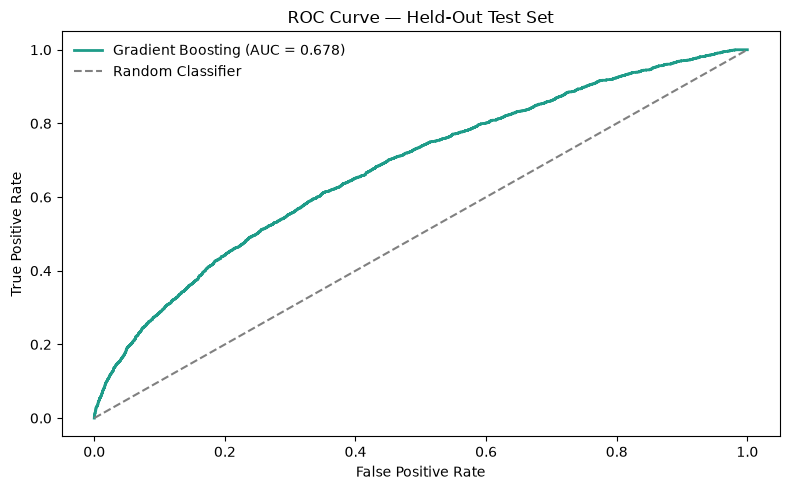

In [12]:
fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    color=plt.cm.viridis(0.55),
    label=f"Gradient Boosting (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Held-Out Test Set")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

The ROC curve remains above the random-classification reference line, with a **ROC-AUC of 0.678**, indicating that the model has a moderate ability to distinguish between encounters that result in 30-day readmission and those that do not.

The curve shows that higher sensitivity can be achieved by accepting a higher false-positive rate, highlighting the trade-off involved when selecting an operating threshold.

While the model demonstrates useful discriminatory ability, the ROC-AUC should be considered alongside Precision–Recall performance because 30-day readmission is relatively uncommon in the dataset.

Precision-Recall Curve

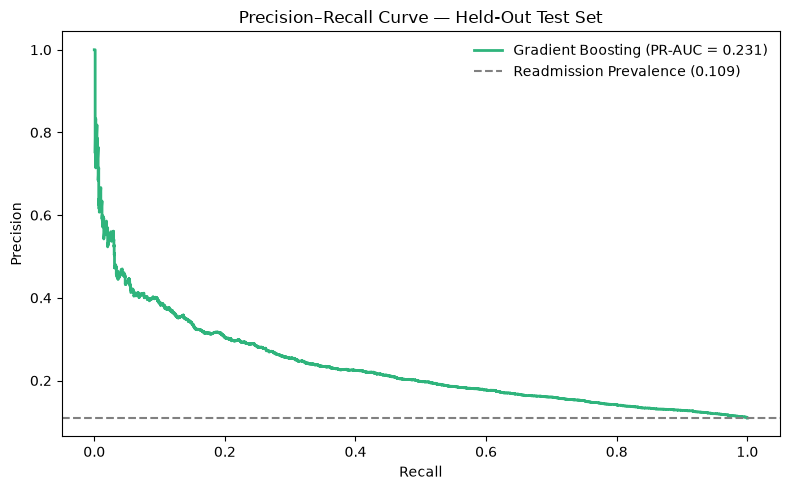

In [13]:
precision, recall, _ = precision_recall_curve(
    y_test,
    test_probabilities
)

pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

baseline = y_test.mean()

plt.figure(figsize=(8, 5))

plt.plot(
    recall,
    precision,
    linewidth=2,
    color=plt.cm.viridis(0.65),
    label=f"Gradient Boosting (PR-AUC = {pr_auc:.3f})"
)

plt.axhline(
    baseline,
    linestyle="--",
    color="grey",
    label=f"Readmission Prevalence ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Held-Out Test Set")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

The Precision–Recall curve remains above the **10.9% readmission prevalence baseline** across most of the recall range, with a **PR-AUC of 0.231**. This indicates that the model provides useful separation of higher-risk encounters despite the imbalanced outcome.

Precision is highest when the model identifies a relatively small proportion of readmissions and declines as recall increases. Therefore, capturing a larger share of actual readmissions requires expanding the number of patients identified as high risk, which also increases false-positive predictions.

This trade-off is particularly relevant for resource allocation, where the preferred operating point depends on the hospital's available post-discharge support capacity.

## 6.5 Threshold Analysis

The default classification threshold of 0.50 identified very few actual readmissions, despite the model demonstrating useful ranking performance.

To examine more practical operating points, classification performance is evaluated across a range of thresholds using the out-of-fold training probabilities. This avoids selecting a threshold based on the held-out test set.

The objective is not to identify a single universally optimal threshold, but to understand how sensitivity and precision change as the threshold is adjusted.

In [14]:
thresholds = np.arange(0.05, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Recall": recall_score(
            y_train, predictions
        ),
        "Precision": precision_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_train, predictions
        ),
        "Patients Flagged (%)": predictions.mean()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df["Patients Flagged (%)"] *= 100

threshold_df.round(3)

,Threshold,Recall,Precision,F1,Patients Flagged (%)
0,0.05,0.978,0.121,0.215,90.666
1,0.10,0.696,0.163,0.264,47.892
2,0.15,0.385,0.218,0.278,19.830
3,0.20,0.210,0.284,0.242,8.293
4,0.25,0.125,0.351,0.184,3.989
5,0.30,0.082,0.395,0.136,2.330
6,0.35,0.052,0.453,0.093,1.286
7,0.40,0.031,0.498,0.058,0.695
8,0.45,0.018,0.536,0.035,0.377
9,0.50,0.011,0.578,0.021,0.212


Lowering the classification threshold substantially increases recall, but also increases the proportion of patients flagged for additional attention.

At a threshold of **0.10**, the model identifies **69.6% of actual readmissions**, but flags approximately **47.9% of encounters**. Raising the threshold to **0.15** reduces the flagged population to **19.8%**, while recall falls to **38.5%**. At **0.20**, only **8.3% of encounters** are flagged, but the model identifies just **21.0% of actual readmissions**.

Precision increases as the threshold rises, reflecting a smaller and more concentrated high-risk group, while recall declines substantially.

These results show that threshold selection represents an operational trade-off rather than a purely statistical optimization problem. In a resource-constrained setting, the preferred operating point should therefore reflect available post-discharge capacity and the proportion of readmissions the hospital aims to reach.

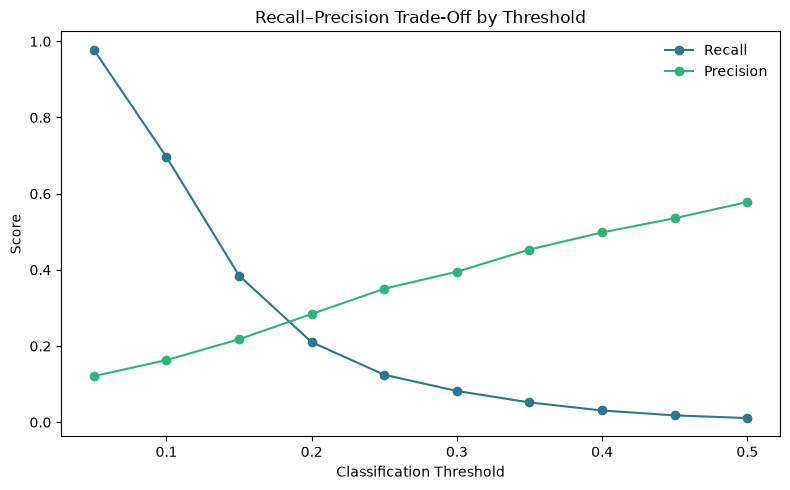

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall",
    color=plt.cm.viridis(0.40)
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision",
    color=plt.cm.viridis(0.65)
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Recall–Precision Trade-Off by Threshold")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

The threshold analysis shows a clear trade-off between recall and precision. Lower thresholds identify a larger proportion of actual readmissions but require substantially more patients to be flagged, while higher thresholds produce a smaller and more precise high-risk group at the cost of missing most readmissions.

For example, a threshold of **0.10** achieves **69.6% recall** but flags **47.9% of encounters**, whereas a threshold of **0.20** reduces the flagged population to **8.3%** while recall falls to **21.0%**.

These results suggest that no single threshold is inherently optimal. The appropriate operating point depends on available post-discharge capacity and the hospital's desired balance between identifying readmissions and limiting the number of patients requiring additional support.

## 6.6 Confusion Matrix

The confusion matrix examines the model's classification behavior on the held-out test set at the default **0.50 threshold**. This provides a concrete view of the very low recall observed during final evaluation and illustrates why the default threshold is not appropriate for identifying patients who may require additional post-discharge support.

In [16]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

cm

array([[17887,    11],
       [ 2178,    17]])

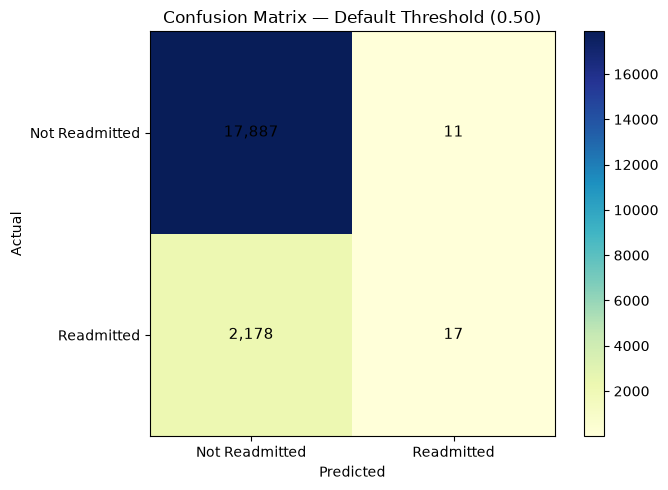

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    cm,
    cmap="YlGnBu"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=11
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Not Readmitted",
    "Readmitted"
])

ax.set_yticklabels([
    "Not Readmitted",
    "Readmitted"
])

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(
    "Confusion Matrix — Default Threshold (0.50)"
)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

At the default **0.50 threshold**, the model correctly identifies only **17 of 2,195 actual readmissions**, while **2,178 readmissions are missed**. In contrast, it correctly classifies 17,887 non-readmitted encounters and produces only 11 false positives.

This pattern explains the model's very low **0.8% recall** and relatively high **60.7% precision** at the default threshold. The model predicts very few encounters as readmissions, making its positive predictions relatively precise but leaving almost all actual readmissions unidentified.

The confusion matrix therefore reinforces that the default 0.50 threshold is unsuitable for the intended decision-support use case. The predicted probabilities are more useful as risk-ranking information than as binary classifications at this cutoff.

## 6.7 Risk Score Distribution

The predicted probabilities are examined by actual readmission outcome to assess how effectively the model separates higher- and lower-risk encounters.A useful risk-ranking model should assign higher predicted probabilities, on average, to encounters that subsequently result in 30-day readmission. The degree of overlap between the two distributions also provides insight into the model's limitations at the individual-patient level.

In [18]:
risk_distribution = pd.DataFrame({
    "Actual Readmission": y_test.values,
    "Predicted Risk": test_probabilities
})

risk_summary = (
    risk_distribution
    .groupby("Actual Readmission")["Predicted Risk"]
    .agg(["mean", "median", "std"])
    .rename(index={
        0: "Not Readmitted",
        1: "Readmitted"
    })
)

risk_summary.round(3)

,mean,median,std
Actual Readmission,,,
Not Readmitted,0.105,0.092,0.061
Readmitted,0.155,0.130,0.094


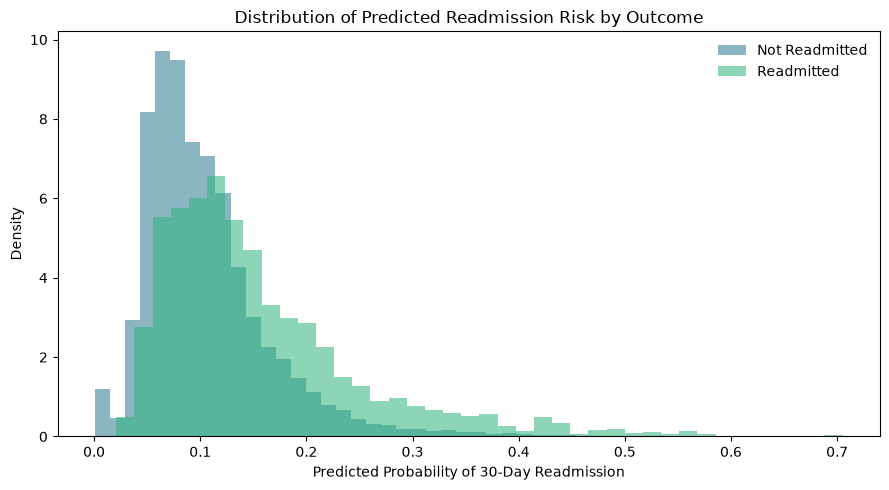

In [19]:
not_readmitted = risk_distribution.loc[
    risk_distribution["Actual Readmission"] == 0,
    "Predicted Risk"
]

readmitted = risk_distribution.loc[
    risk_distribution["Actual Readmission"] == 1,
    "Predicted Risk"
]

plt.figure(figsize=(9, 5))

plt.hist(
    not_readmitted,
    bins=40,
    density=True,
    alpha=0.55,
    color=plt.cm.viridis(0.40),
    label="Not Readmitted"
)

plt.hist(
    readmitted,
    bins=40,
    density=True,
    alpha=0.55,
    color=plt.cm.viridis(0.65),
    label="Readmitted"
)

plt.xlabel("Predicted Probability of 30-Day Readmission")
plt.ylabel("Density")
plt.title("Distribution of Predicted Readmission Risk by Outcome")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

Encounters resulting in 30-day readmission received higher predicted risk scores, with a **mean predicted probability of 15.5%** compared with **10.5%** among encounters that were not readmitted. Median predicted risk was similarly higher for readmitted encounters (**13.0% vs. 9.2%**).

The distribution for readmitted encounters is shifted toward higher predicted probabilities and extends further into the high-risk range. However, substantial overlap remains between the two outcome groups, indicating that the model does not cleanly separate readmitted from non-readmitted patients at the individual level.

The results therefore support using predicted probabilities primarily for **relative risk ranking and prioritization**, rather than interpreting them as definitive predictions of whether an individual patient will be readmitted.